In [1]:
# plot_spatial.ipynb

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

In [3]:
root_dir = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/cna_prediction/1n1t_s1600/downsample_ref'
out_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/cna_prediction/1n1t_s1600/downsample_ref/analysis/calicost_spatial_pos"

In [4]:
os.makedirs(out_dir, exist_ok = True)

In [5]:
run_id_list = [d for d in os.listdir(root_dir) if d.startswith('ds_')]
run_id_list

['ds_30', 'ds_10', 'ds_600', 'ds_3', 'ds_100', 'ds_300']

plot 'ds_30' ...
41 63
plot 'ds_10' ...
41 63
plot 'ds_600' ...
63 63
plot 'ds_3' ...
41 63
plot 'ds_100' ...
43 63
plot 'ds_300' ...
51 63


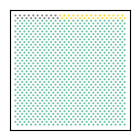

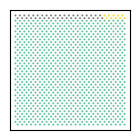

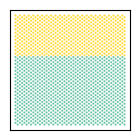

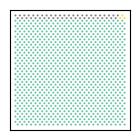

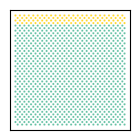

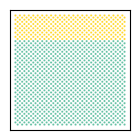

In [6]:
cmap = plt.cm.Set2
custom_colors = {
    'out_tissue': 'grey',
    'normal': cmap(5),    # here normal is ref.
    'tumor': cmap(0)
}

for run_id in run_id_list:
    print("plot '%s' ..." % run_id)
    fn = os.path.join(root_dir, '%s/gen_data/ps_spaceranger/spatial/tissue_positions_list_clone.csv' % run_id)
    df = pd.read_csv(fn)
    
    df['x'] = df['array_row']
    df['y'] = max(df['array_col']) - df['array_col']
    y_max = df.loc[df['clone'] == 'normal', 'y'].max()
    print(y_max, df['y'].max())
    df = df.loc[df['y'] <= y_max].copy()

    fig = plt.figure(figsize = (1.5, 1.5))
    sns.scatterplot(
        data = df, x = 'x', y = 'y', 
        hue = 'clone', s = 2.5, palette = custom_colors
    )
    #plt.legend(loc = 'lower center', bbox_to_anchor = (0.46, 0.97), frameon = False, ncol = 2, handletextpad = -0.5)
    #plt.legend(loc = 'center left', bbox_to_anchor = (0.95, 0.5), frameon = False, handletextpad = -0.3)
    plt.gca().get_legend().remove()
    plt.xticks([])
    plt.yticks([])
    plt.xlabel(None)
    plt.ylabel(None)
    plt.tight_layout()

    plt.savefig(
        fname = os.path.join(out_dir, '%s_spatial.png' % run_id), 
        dpi = 300, 
        bbox_inches = 'tight'
    )